# Dataset

The dataset used in this notebook is the [Medical Meadow Medical Flashcards](https://huggingface.co/datasets/medalpaca/medical_meadow_medical_flashcards) available in the Hugging Face Datasets library.

To use this dataset and analyze it, we create a dataframe using the `panda` package

In [ ]:
df = pd.DataFrame(original)

The dataset consists of medical flashcards created by medical students, covering a wide range of subjects necessary for medical practice. It contains concise summaries and mnemonics to help with learning and retention of medical concepts.

According to the paper, the flashcards were converted into question-answer pairs using OpenAI's GPT-3.5-turbo, after removing cards containing images.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33955 entries, 0 to 33954
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  33955 non-null  object
 1   input        33955 non-null  object
 2   output       33955 non-null  object
dtypes: object(3)
memory usage: 795.9+ KB


## Dataset overview

Before starting to analyze the flashcard dataset, let's see what it looks like, by printing the first few examples of the data frame we loaded.

In [ ]:
df.head()

,instruction,input,output
0,Answer this question truthfully,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...
1,Answer this question truthfully,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...
2,Answer this question truthfully,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...
3,Answer this question truthfully,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca..."
4,Answer this question truthfully,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...


As we can see, the dataset has 3 columns:

- `instruction`: the instruction to be followed to properly answer to the question (in this dataset, the instruction is always "Answer this question truthfully")
- `input`: the medical question
- `output`: the answer to the question

Now, let's see how many examples we have in the dataset

In [ ]:
print("Number of elements:", len(original))

Number of elements: 33955


In [ ]:
df.describe()

,instruction,input,output
count,33955,33955,33955
unique,1,33289,33335
top,Answer this question truthfully,,
freq,33955,408,402


## Preprocessing

### Removing duplicates and useless elements

As we can see from the `df.describe()` output cell, in the dataset we have that the column `instruction` has only one unique value, so we can drop it. Also, the input and the output columns have some duplicates, so we can drop them as well.

If there are any missing values, we will drop them as well.

In [ ]:
# Group by both question and answer columns and count occurrences
qa_counts = df.groupby(['input', 'output']).size().reset_index(name='count')

# Filter out pairs that occur more than once
repeating_qa_pairs = qa_counts[qa_counts['count'] > 1]
df_unique = df.drop_duplicates(subset=['input', 'output'], keep='first')

print(f"Removed", len(df) - len(df_unique), "duplicated elements")

Removed 427 duplicated elements


In [ ]:
# count of unique value for each column in the dataset
df.nunique()

instruction        1
input          33289
output         33335
dtype: int64

### Tokenization

Another useful step is to tokenize the dataset. We will use the `word_tokenize` function from the `nltk` library to tokenize the input and output columns.

First, in order to keep the dataframe intact, we will create a copy of it

In [ ]:
df_unique = df_unique.copy()

then we will tokenize the input and output and mark the tokenized columns as `tokens_question` and `tokens_answer`

In [ ]:
# Tokenize text in 'input' and 'output' columns
df_unique['tokens_questions'] = df_unique['input'].apply(lambda x: word_tokenize(x))
df_unique['tokens_answers'] = df_unique['output'].apply(lambda x: word_tokenize(x))

and, as a final step, we combine the tokenized columns into a single tokenized list marked as `combined_tokens`

In [ ]:
# Combine tokens from both columns into a single list
df_unique['combined_tokens'] = df_unique.apply(lambda row: row['tokens_questions'] + row['tokens_answers'], axis=1)

We can see an example of the tokenized process by printing an element from the `df_unique` dataframe we created earlier

In [ ]:
x = np.random.randint(0, len(df_unique))

print(df_unique.iloc[x])
print(df_unique['combined_tokens'][x])
print(df_unique['tokens_answers'][x])
print(df_unique['tokens_questions'][x])
print(df_unique['input'][x])
print(df_unique['output'][x])

instruction                           Answer this question truthfully
input               What is the name of the infectious skin disord...
output              The infectious skin disorder that is caused by...
tokens_questions    [What, is, the, name, of, the, infectious, ski...
tokens_answers      [The, infectious, skin, disorder, that, is, ca...
combined_tokens     [What, is, the, name, of, the, infectious, ski...
Name: 6116, dtype: object
['What', 'is', 'the', 'name', 'of', 'the', 'inflammatory', 'dermatitis', 'that', 'is', 'characterized', 'by', 'hypergranulosis', '?', 'The', 'inflammatory', 'dermatitis', 'that', 'presents', 'with', 'hypergranulosis', 'is', 'called', 'lichen', 'planus', '.', 'Lichen', 'planus', 'is', 'a', 'common', 'skin', 'condition', 'that', 'can', 'affect', 'various', 'parts', 'of', 'the', 'body', ',', 'including', 'the', 'skin', ',', 'mouth', ',', 'nails', ',', 'and', 'scalp', '.', 'It', 'is', 'characterized', 'by', 'small', ',', 'itchy', ',', 'flat-topped', ',

### Remove punctuation from the dataset

Now that we have tokenized the dataset, it is possible to remove punctuation from the dataset, because they are not useful for the model training.

To remove them, we will use the `string` library to get the list of punctuation characters remove the tokens that are in the list of `punctuation` characters

In [ ]:
df_unique['tokens_answers'] = df_unique['tokens_answers'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])
df_unique['tokens_questions'] = df_unique['tokens_questions'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])
df_unique['combined_tokens'] = df_unique['combined_tokens'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])

## Exploratory data analysis

Our dataset is ready for the exploratory data analysis in order to understand the data better.

We will:

1. analyze the length of the questions and the answers inside the dataset
2. visualize the most frequent words
3. find what are the main topics
4. check if the question appears in the answer or not

### Text length analysis

The first kind of analysis we can perform is the length analysis. We will plot the distribution of the tokens of the `input` and the `output` and the mean length of the data.

Let's start with the `input`

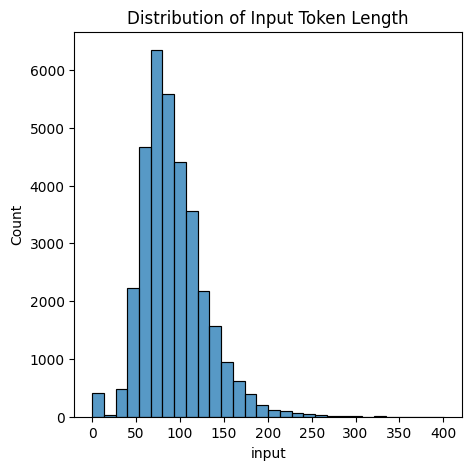

Mean token length for input: 92.40477102046826
Median token length for input: 87.0


In [ ]:
# Distribution of token lengths for input
plt.figure(figsize=(5, 5))
sns.histplot(df['input'].apply(len), bins=30)
plt.title('Distribution of Input Token Length')
plt.show()

# mean and median token length for input
print('Mean token length for input:', df['input'].apply(len).mean())
print('Median token length for input:', df['input'].apply(len).median())

and now let's see the same plot for the `output`

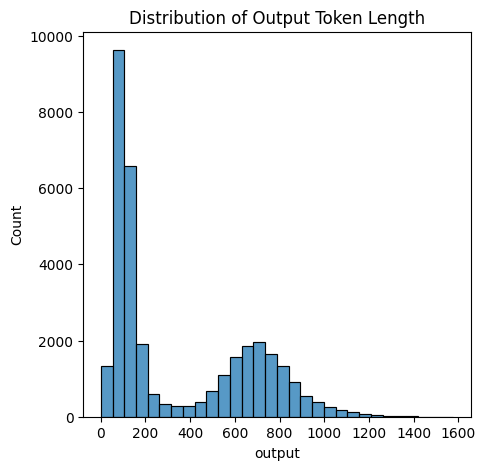

Mean token length for output: 349.0955971138271
Median token length for output: 150.0


In [ ]:
# Distribution of token lengths for output
plt.figure(figsize=(5, 5))
sns.histplot(df['output'].apply(len), bins=30)
plt.title('Distribution of Output Token Length')
plt.show()

# mean and median token length for output
print('Mean token length for output:', df['output'].apply(len).mean())
print('Median token length for output:', df['output'].apply(len).median())

As we can see here, the length of the responses are much smaller than the length of the questions; there are also a small (but not negligible) number of responses with an higher length, but the majority of the responses are shorter than 200 tokens (similar to the questions).

### Most frequent words

Now, let's visualize the most frequent words in the dataset.

In order to do that, we will use the `Counter` class from the `collections` library to count the frequency of each word in the `combined_tokens` column; then, we plot the 10 most common words in the dataset.

In [ ]:
# Flatten the list of tokens
flat_tokens = [word for sublist in df_unique['combined_tokens'] for word in sublist]

# Count the frequency of each word
word_freq = Counter(flat_tokens)

# Get the top N most frequent words
top_n = 10  # Number of most frequent words to display
most_common_words = word_freq.most_common(top_n)

# Extract words and frequencies for plotting
words, frequencies = zip(*most_common_words)

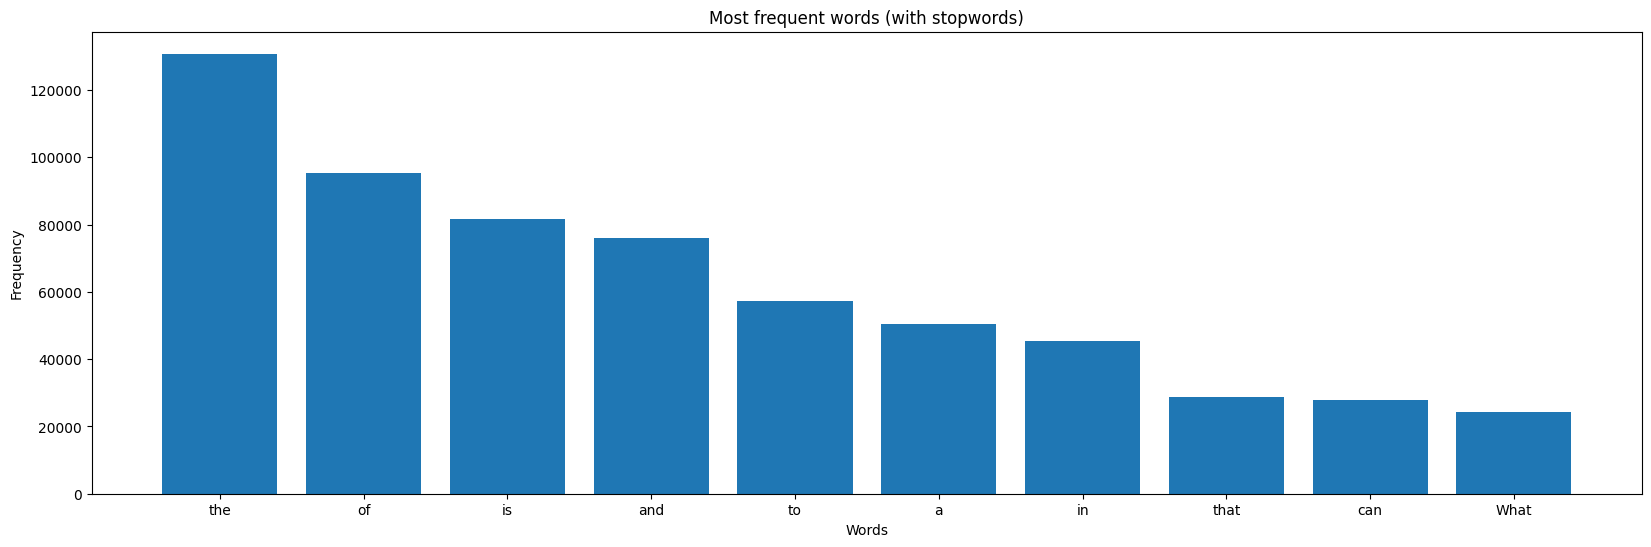

In [ ]:
# Plot the frequency distribution
plt.figure(figsize=(20, 6))
plt.bar(words, frequencies)
plt.title('Most frequent words (with stopwords)'.format(top_n))
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

As expected, the most common words are stopwords, because all the questions and the answers are written in natural language.

To get a better understanding of the dataset, we can remove the stopwords from the dataset and plot the most common words again. To get the stop words, we will use the `stopwords` list from the `nltk` library.

In [ ]:
nltk.download('stopwords')

# Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in flat_tokens if word.lower() not in stop_words]

# Count the frequency of each word
word_freq = Counter(filtered_tokens)

# Get the top N most frequent words
top_n = 10  # Number of most frequent words to display
most_common_words = word_freq.most_common(top_n)

# Extract words and frequencies for plotting
words, frequencies = zip(*most_common_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


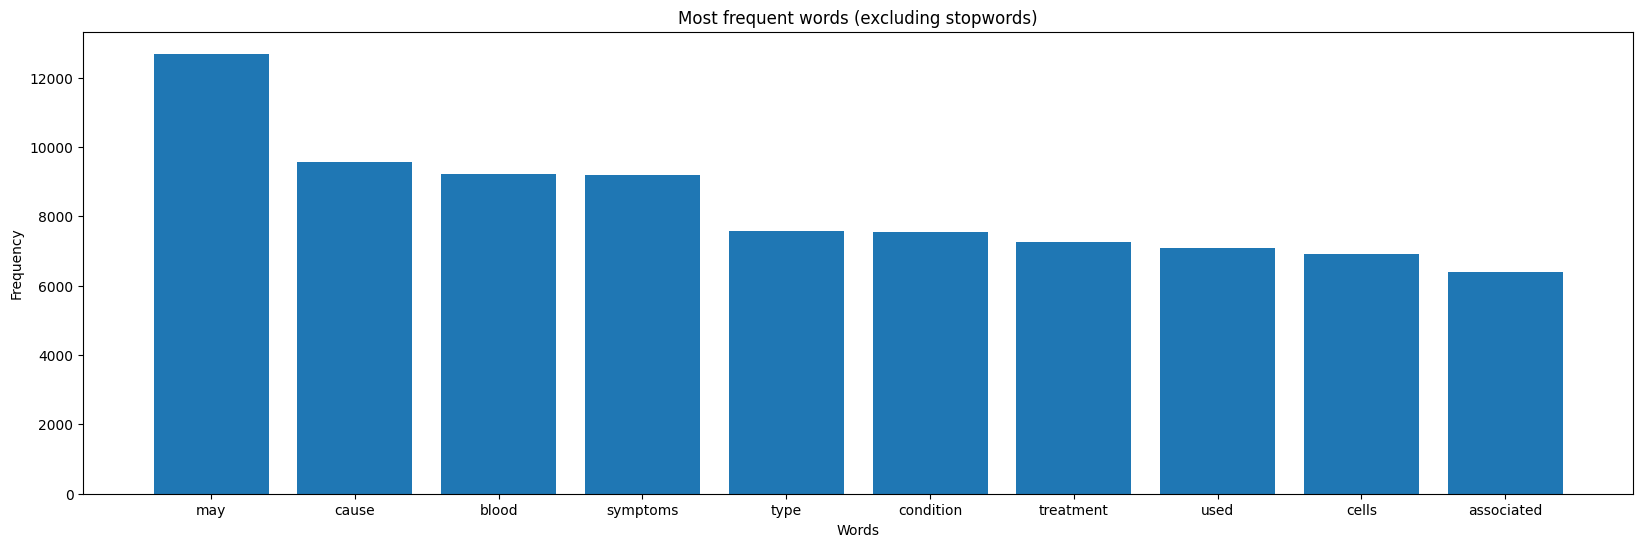

In [ ]:
# Plot the frequency distribution
plt.figure(figsize=(20, 6))
plt.bar(words, frequencies)
plt.title('Most frequent words (excluding stopwords)'.format(top_n))
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

By removing the stopwords, we obtain a more meaningful list of the most common words in the dataset. As expected, the most common words are related to the medical field, which is the main topic of the dataset.

We can also plot the wordcloud of the most common words in the tokenized space to get a better (and funnier) visualization of the most common terms in the dataset (just for fun).

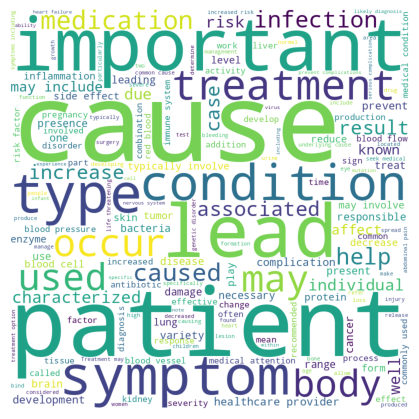

In [ ]:

# Generate word cloud for output
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', stopwords = None, min_font_size = 10).generate(' '.join(df['output']))

# plot the WordCloud image
plt.figure(figsize = (4,4), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()

### Topics analysis

We can also analyze the topics and categories of the questions in the dataset.

Before starting, we need to define how many clusters (so topics) we want to find in the dataset. We can use the `KMeans` algorithm from the `sklearn` library to find the optimal number of clusters.

The first thing to do is to prepare a `data_pairs` list that will contains our input and output pairs, and use them to create a `TfidfVectorizer` object to transform the data into a matrix of TF-IDF features.

In [ ]:
data_pairs = []
# Iterate over dialogues
for index, row in df_unique.iterrows():
    # Add pair to collection
    data_pairs.append({'message': row['input'], 'response': row['output']})

documents = [f"{sample['message']}\n\n{sample['response']}" for sample in data_pairs]

In [ ]:
vectorizer = TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')
vectorizer.fit(documents)

TfidfVectorizer(max_df=0.8, min_df=5, stop_words='english')

And then, we create the vector representation of the documents using the `transform()` method

In [ ]:
vector_documents = vectorizer.transform(documents)

Once we have the vector representation of the documents, we can use the `MiniBatchKMeans` algorithm to find the optimal number of clusters in the dataset.

First, we will define the the `MiniBatchKMeans` object and then we will fit the model to the data

In [ ]:
k = 10

mb_kmeans = MiniBatchKMeans(n_clusters=k,batch_size=500, random_state=2307)
mb_kmeans.fit(vector_documents)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


MiniBatchKMeans(batch_size=500, n_clusters=10, random_state=2307)

then compute the `inertia` of the model, which is the sum of squared distances of samples to their closest cluster center, and plot the inertia values for different numbers of clusters

In [ ]:
performance = [MiniBatchKMeans(n_clusters=k, batch_size=500, random_state=2307).fit(vector_documents).inertia_ for k in range(1,50)]

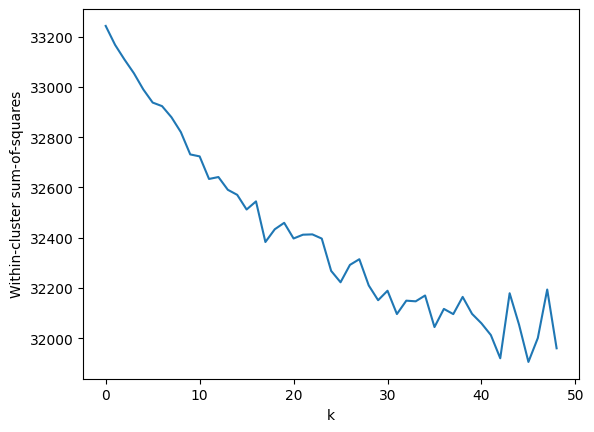

In [ ]:
plt.figure()
plt.plot(performance)
plt.ylabel('Within-cluster sum-of-squares')
plt.xlabel('k')
plt.show()

In order to find the optimal number of clusters, we can use the `KneeLocator` class from the `kneed` library to find the elbow point in the inertia plot

In [ ]:
kl = KneeLocator(range(1, 50), performance, curve="convex", direction="decreasing")
print("Elbow point is at k =", kl.elbow)

Elbow point is at k = 12


Now that we have the optimal number of clusters, we can try to find the terms that are most important in each cluster. To do that, we use the `KMeans` algorithm to fit the model to the data using, as the `n_clusters` parameter, the optimal number of clusters we found earlier.

In [ ]:
k = kl.elbow

kmeans = KMeans(n_clusters=k, max_iter=100, n_init=2, verbose=True, random_state=2307)
kmeans.fit(vector_documents)

and then we print the most important terms in each cluster

In [ ]:
print("Top terms per cluster:")
vocab = vectorizer.get_feature_names_out()

for i in range(kmeans.n_clusters):
    centroid = kmeans.cluster_centers_[i]
    sorted_terms = centroid.argsort()[::-1]
    print(f"Cluster {i}:\t{[vocab[j] for j in sorted_terms[:10]]}")

Top terms per cluster:
Cluster 0:	['cells', 'cell', 'blood', 'type', 'immune', 'red', 'anemia', 'lymphoma', 'sickle', 'response']
Cluster 1:	['syndrome', 'associated', 'symptoms', 'condition', 'disorder', 'cause', 'characterized', 'caused', 'patients', 'nephrotic']
Cluster 2:	['type', 'does', 'nerve', 'cause', 'used', 'typically', 'effect', 'enzyme', 'responsible', 'characterized']
Cluster 3:	['associated', 'commonly', 'type', 'risk', 'condition', 'adverse', 'disease', 'increased', 'effect', 'use']
Cluster 4:	['heart', 'blood', 'pressure', 'failure', 'cardiac', 'pulmonary', 'flow', 'left', 'hypertension', 'valve']
Cluster 5:	['infection', 'bacteria', 'infections', 'virus', 'bacterial', 'cause', 'antibiotics', 'gram', 'treatment', 'used']
Cluster 6:	['levels', 'hormone', 'thyroid', 'serum', 'calcium', 'blood', 'low', 'insulin', 'increased', 'glucose']
Cluster 7:	['cancer', 'carcinoma', 'cell', 'risk', 'breast', 'type', 'lung', 'squamous', 'associated', 'cells']
Cluster 8:	['class', 'bel

In [ ]:
# save the centroids for later use
centroids = kmeans.cluster_centers_

For an alternative perspective, we can plot the distribution of the words for each topic

In [ ]:
def display_topics_bar(feature_names, no_top_words):
    fig, axs = plt.subplots(k // 2, 2, figsize=(20, 20))
    axs = axs.flatten()
    for i in range(kmeans.n_clusters):
        centroid = kmeans.cluster_centers_[i]
        sorted_terms = centroid.argsort()[::-1]
        words = [feature_names[j] for j in sorted_terms[:no_top_words]]
        freqs = centroid[sorted_terms][:no_top_words]
        axs[i].barh(words, freqs)
        axs[i].set_title(f"Cluster {i}")
    plt.tight_layout()
    plt.show()

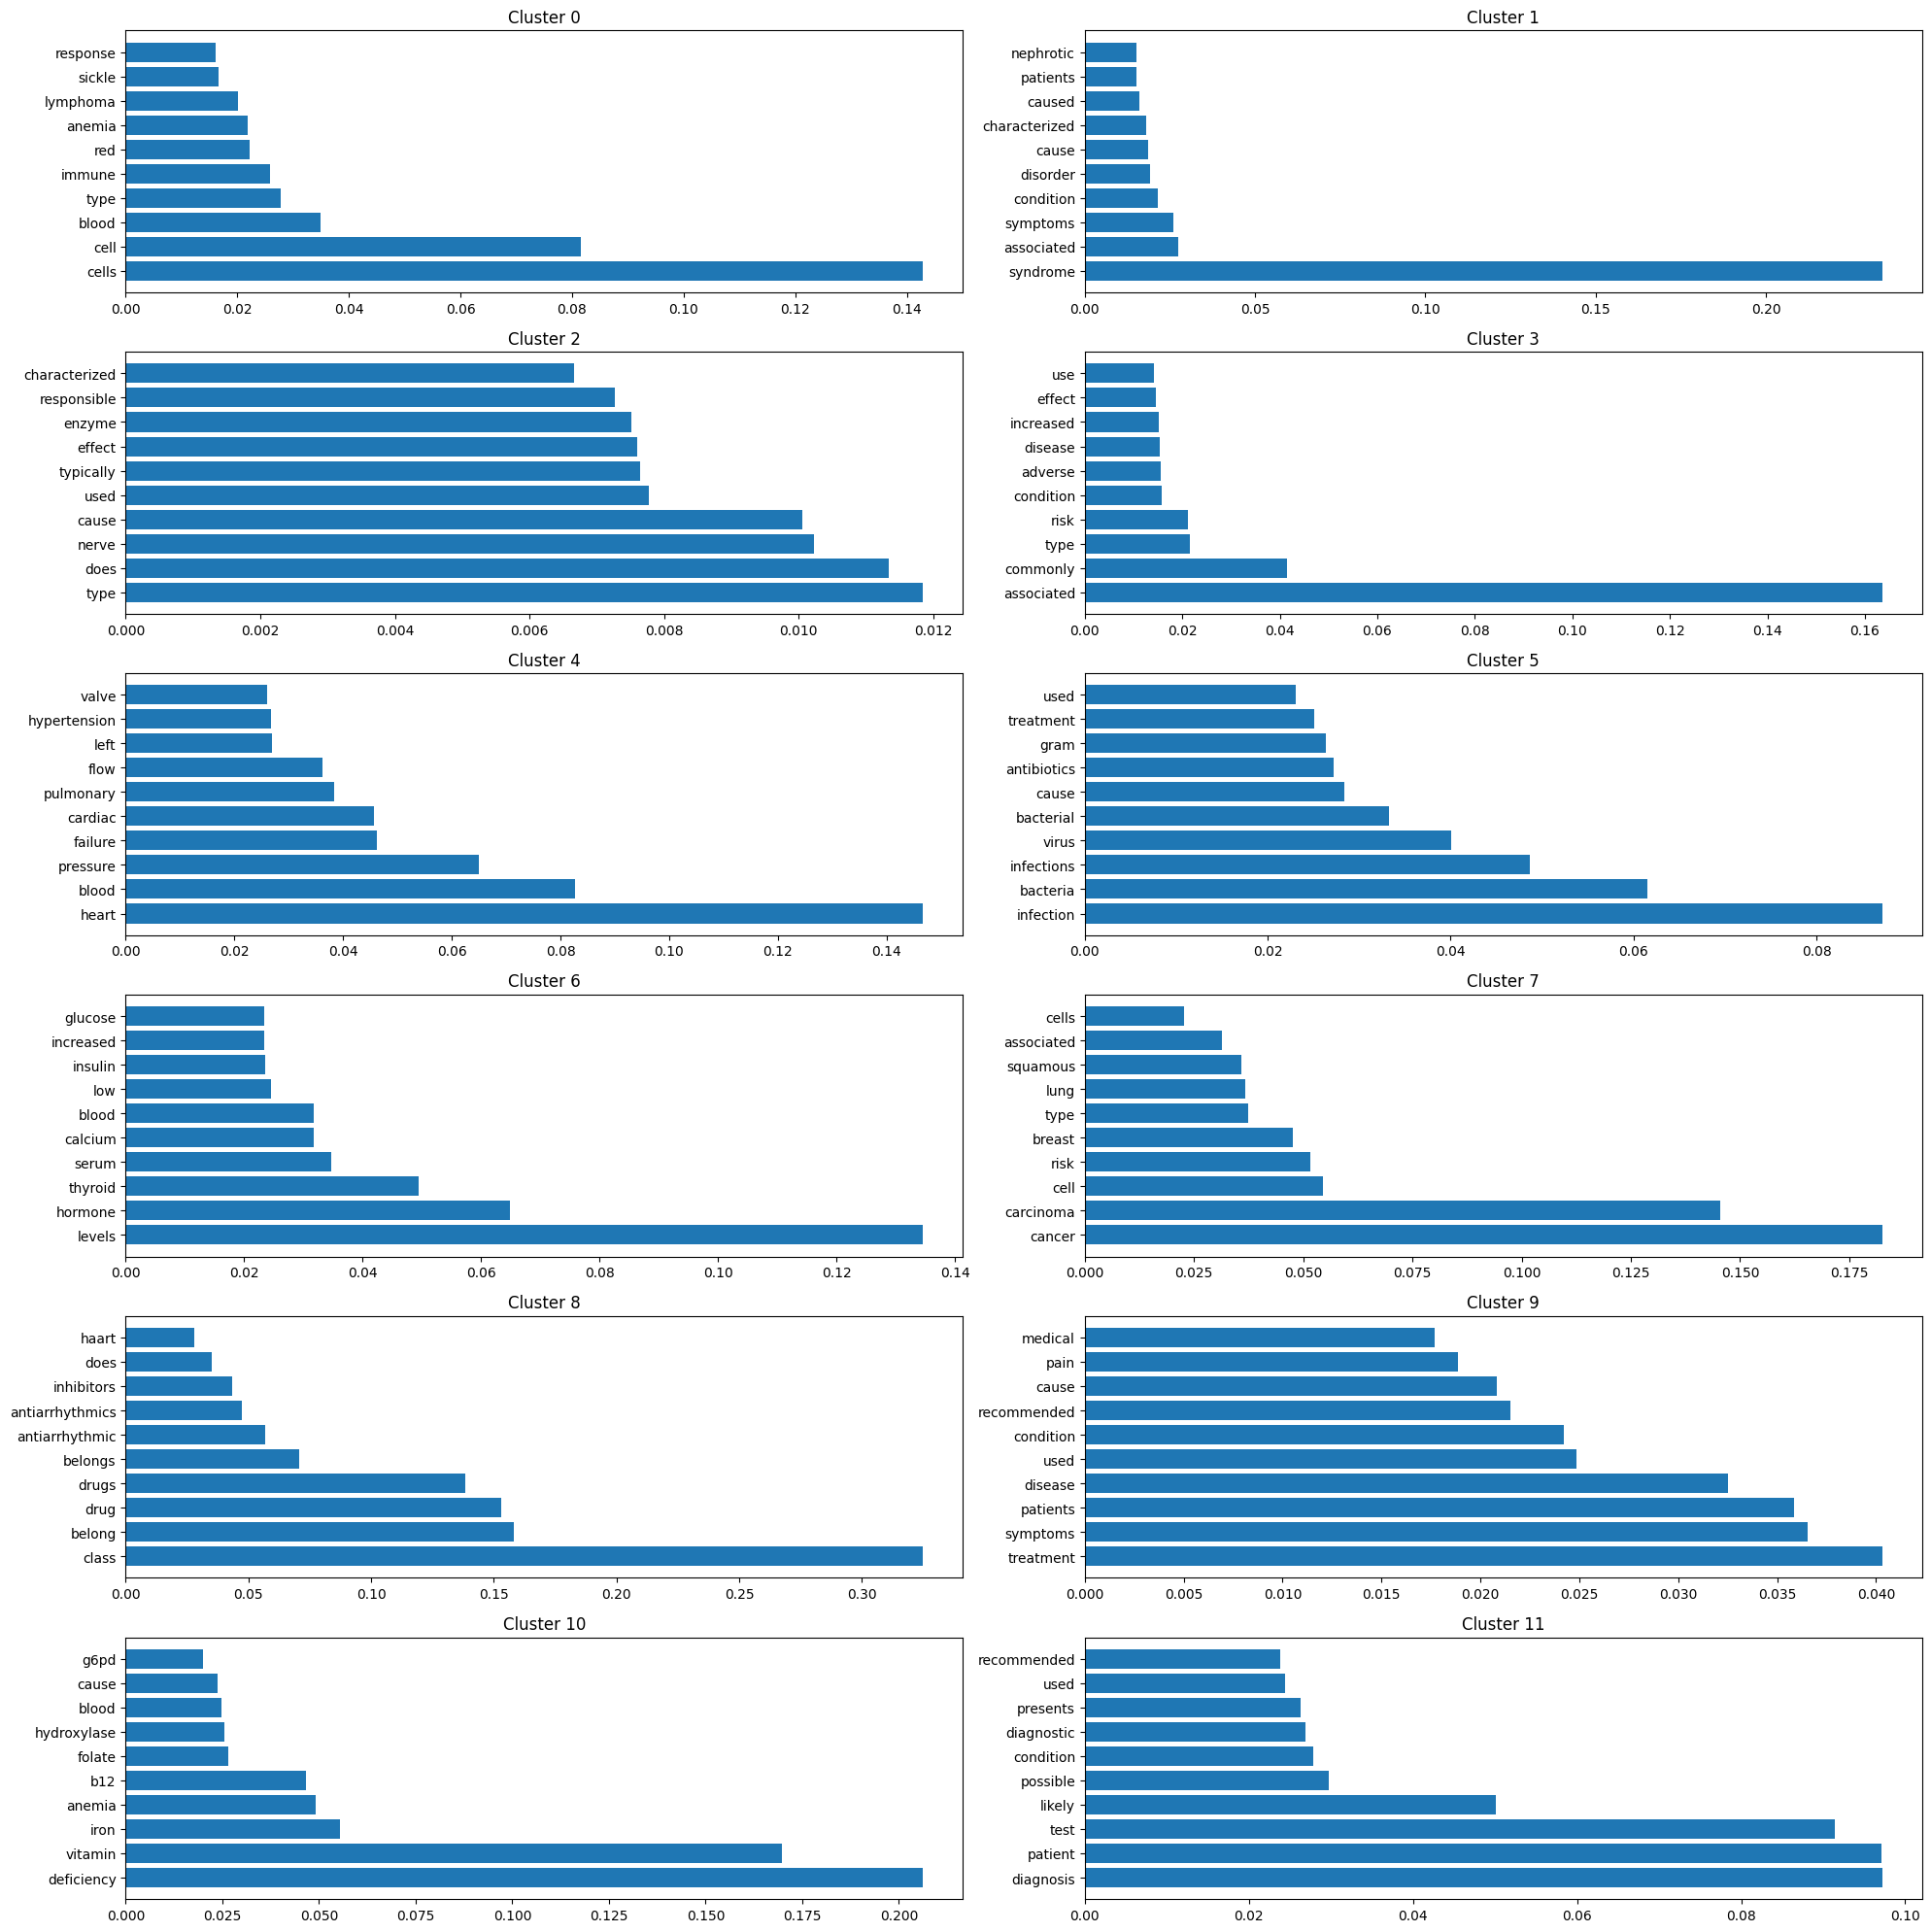

In [ ]:
display_topics_bar(vocab, 10)

and the distribution of them according to our dataset

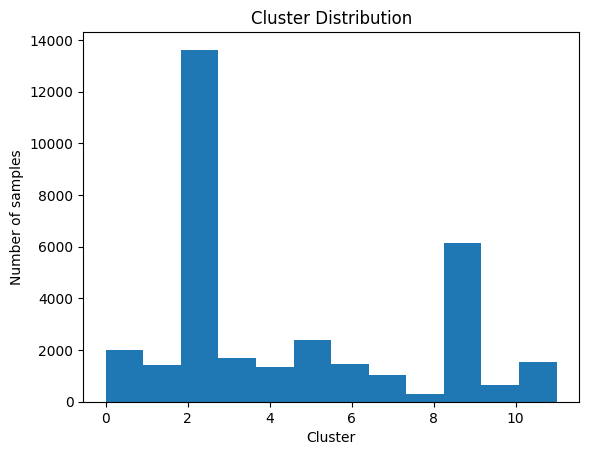

In [ ]:
# plot the distribution of clusters
plt.hist(kmeans.labels_, bins=k)
plt.title('Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of samples')
plt.show()

In [ ]:
df_unique['cluster'] = kmeans.labels_

# Display the first few rows of the DataFrame
df_unique.head()

,instruction,input,output,tokens_questions,tokens_answers,combined_tokens,cluster
0,Answer this question truthfully,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...,"[What, is, the, relationship, between, very, l...","[Very, low, Mg2+, levels, correspond, to, low,...","[What, is, the, relationship, between, very, l...",6
1,Answer this question truthfully,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...,"[What, leads, to, genitourinary, syndrome, of,...","[Low, estradiol, production, leads, to, genito...","[What, leads, to, genitourinary, syndrome, of,...",1
2,Answer this question truthfully,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...,"[What, does, low, REM, sleep, latency, and, ex...","[Low, REM, sleep, latency, and, experiencing, ...","[What, does, low, REM, sleep, latency, and, ex...",2
3,Answer this question truthfully,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca...","[What, are, some, possible, causes, of, low, P...","[PTH-independent, hypercalcemia, which, can, b...","[What, are, some, possible, causes, of, low, P...",6
4,Answer this question truthfully,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...,"[How, does, the, level, of, anti-müllerian, ho...","[The, level, of, anti-müllerian, hormone, is, ...","[How, does, the, level, of, anti-müllerian, ho...",2


For the evaluation of the computation we have done, we can display the metrics coming from the`inertia` and the `silhouette` score

In [ ]:
print("Intrinsic evaluation measures:")
print("Within-cluster sum-of-squares:", str(kmeans.inertia_))
print("Silhouette coefficient:", str(metrics.silhouette_score(vector_documents, kmeans.labels_)))

Intrinsic evaluation measures:
Within-cluster sum-of-squares: 32567.36156331283
Silhouette coefficient: 0.0048736832742096335


### Quenstion tokens in the answer

Another interesting analysis we can do is to check if the question appears in the answer.

We can use the `df_unique` dataframe we created earlier and check how many tokens from the question appear in the answer.

In [ ]:
# Create a copy of the DataFrame
df_w2v = df_unique.copy()

# drop columns that are not needed (like combined_tokens)
df_w2v.drop(columns=['combined_tokens'], inplace=True)

In [ ]:
def count_common_tokens(row):
    return len(set(row['tokens_questions']).intersection(row['tokens_answers']))

Now, we add a column to the `df_w2v` dataframe that contains the number of tokens from the question that appear in the answer.

In [ ]:
df_w2v['occurrences'] = df_unique.apply(count_common_tokens, axis=1)

and we can compute the percentage of tokens that appear in the answer for each question.

In [ ]:
df_w2v['common_tokens_percentage'] = df_w2v['occurrences'] / df_w2v['tokens_questions'].apply(len)

df_w2v.head()

,instruction,input,output,tokens_questions,tokens_answers,cluster,occurrences,common_tokens_percentage
0,Answer this question truthfully,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...,"[What, is, the, relationship, between, very, l...","[Very, low, Mg2+, levels, correspond, to, low,...",6,5,0.357143
1,Answer this question truthfully,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...,"[What, leads, to, genitourinary, syndrome, of,...","[Low, estradiol, production, leads, to, genito...",1,8,0.888889
2,Answer this question truthfully,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...,"[What, does, low, REM, sleep, latency, and, ex...","[Low, REM, sleep, latency, and, experiencing, ...",2,7,0.636364
3,Answer this question truthfully,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca...","[What, are, some, possible, causes, of, low, P...","[PTH-independent, hypercalcemia, which, can, b...",6,0,0.000000
4,Answer this question truthfully,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...,"[How, does, the, level, of, anti-müllerian, ho...","[The, level, of, anti-müllerian, hormone, is, ...",2,7,0.636364


## Support datasets

After the analysis of the medical flashcards dataset, we can analyze other medical datasets that can be useful for the training and the evaluation of the model. In the [paper](https://arxiv.org/pdf/2304.08247.pdf) that was provided, the authors used the Wikidoc and the MedQA datasets to train the model.

So, we will analyze these datasets to understand their structure and the data they contain.

### Wikidoc

As we have done for the medical flashcards dataset, we will load the Wikidoc dataset and create a dataframe to analyze it.

In [ ]:
df_wikidoc = pd.DataFrame(wikidoc)
df_wikidoc.head()

,input,output
0,Can you provide an overview of the lung's squa...,Squamous cell carcinoma of the lung may be cla...
1,"What does ""Clear: cell"" mean?",Clear cell tumors are part of the surface epit...
2,Can you provide me with information regarding ...,Two Japanese scientists commenced research int...
3,What are the historical background and symptom...,Symptoms of vulvovaginitis caused by Candida s...
4,"What does the ""Hypotension: Resident Survival ...",Hypotension is the term for low blood pressure...


In this case, we only have two columns: `input` and `output`, which are the question and the answer, respectively.

In [ ]:
df_wikidoc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   10000 non-null  object
 1   output  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


Now that we have loaded the dataset, let's see how many examples we have in the dataset.

In [ ]:
len(df_wikidoc)

10000

And we can start by removing all the duplicates from the dataset,

In [ ]:
def remove_duplicates(df):
    qa_counts = df.groupby(['input', 'output']).size().reset_index(name='count')
    repeating_qa_pairs = qa_counts[qa_counts['count'] > 1]
    df_unique = df.drop_duplicates(subset=['input', 'output'], keep='first')
    print(f"Removed {len(df) - len(df_unique)} duplicated elements")
    return df_unique

In [ ]:
remove_duplicates(df_wikidoc)

df_wikidoc.head()

Removed 0 duplicated elements


,input,output
0,Can you provide an overview of the lung's squa...,Squamous cell carcinoma of the lung may be cla...
1,"What does ""Clear: cell"" mean?",Clear cell tumors are part of the surface epit...
2,Can you provide me with information regarding ...,Two Japanese scientists commenced research int...
3,What are the historical background and symptom...,Symptoms of vulvovaginitis caused by Candida s...
4,"What does the ""Hypotension: Resident Survival ...",Hypotension is the term for low blood pressure...


lowercase the input and output columns,

In [ ]:
def lowecase(df):
    df['input'] = df['input'].str.lower()
    df['output'] = df['output'].str.lower()
    return df

df_wikidoc = lowecase(df_wikidoc)

and tokenize the dataset and remove the punctuation from the dataset

In [ ]:
def tokenize(df):
    df['tokens_questions'] = df['input'].apply(lambda x: word_tokenize(x))
    df['tokens_answers'] = df['output'].apply(lambda x: word_tokenize(x))
    df['combined_tokens'] = df.apply(lambda row: row['tokens_questions'] + row['tokens_answers'], axis=1)
    return df

def remove_punctuation(df):
    df['tokens_answers'] = df['tokens_answers'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])
    df['tokens_questions'] = df['tokens_questions'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])
    df['combined_tokens'] = df['combined_tokens'].apply(lambda tokens: [token for token in tokens if token not in string.punctuation])
    return df

In [ ]:
tokenize(df_wikidoc)
remove_punctuation(df_wikidoc)
df_wikidoc.head()

,input,output,tokens_questions,tokens_answers,combined_tokens
0,can you provide an overview of the lung's squa...,squamous cell carcinoma of the lung may be cla...,"[can, you, provide, an, overview, of, the, lun...","[squamous, cell, carcinoma, of, the, lung, may...","[can, you, provide, an, overview, of, the, lun..."
1,"what does ""clear: cell"" mean?",clear cell tumors are part of the surface epit...,"[what, does, ``, clear, cell, '', mean]","[clear, cell, tumors, are, part, of, the, surf...","[what, does, ``, clear, cell, '', mean, clear,..."
2,can you provide me with information regarding ...,two japanese scientists commenced research int...,"[can, you, provide, me, with, information, reg...","[two, japanese, scientists, commenced, researc...","[can, you, provide, me, with, information, reg..."
3,what are the historical background and symptom...,symptoms of vulvovaginitis caused by candida s...,"[what, are, the, historical, background, and, ...","[symptoms, of, vulvovaginitis, caused, by, can...","[what, are, the, historical, background, and, ..."
4,"what does the ""hypotension: resident survival ...",hypotension is the term for low blood pressure...,"[what, does, the, ``, hypotension, resident, s...","[hypotension, is, the, term, for, low, blood, ...","[what, does, the, ``, hypotension, resident, s..."


After that, we can find the most common words in the dataset and plot them using a bar chart.

In [ ]:
# remove stopwords from the dataset
def remove_stopwords(df):
    df['tokens_answers'] = df['tokens_answers'].apply(lambda tokens: [token for token in tokens if token not in stop_words])
    df['tokens_questions'] = df['tokens_questions'].apply(lambda tokens: [token for token in tokens if token not in stop_words])
    df['combined_tokens'] = df['combined_tokens'].apply(lambda tokens: [token for token in tokens if token not in stop_words])
    return df

remove_stopwords(df_wikidoc)
df_wikidoc.head()

,input,output,tokens_questions,tokens_answers,combined_tokens
0,can you provide an overview of the lung's squa...,squamous cell carcinoma of the lung may be cla...,"[provide, overview, lung, 's, squamous, cell, ...","[squamous, cell, carcinoma, lung, may, classif...","[provide, overview, lung, 's, squamous, cell, ..."
1,"what does ""clear: cell"" mean?",clear cell tumors are part of the surface epit...,"[``, clear, cell, '', mean]","[clear, cell, tumors, part, surface, epithelia...","[``, clear, cell, '', mean, clear, cell, tumor..."
2,can you provide me with information regarding ...,two japanese scientists commenced research int...,"[provide, information, regarding, statins]","[two, japanese, scientists, commenced, researc...","[provide, information, regarding, statins, two..."
3,what are the historical background and symptom...,symptoms of vulvovaginitis caused by candida s...,"[historical, background, symptoms, candida-ind...","[symptoms, vulvovaginitis, caused, candida, sp...","[historical, background, symptoms, candida-ind..."
4,"what does the ""hypotension: resident survival ...",hypotension is the term for low blood pressure...,"[``, hypotension, resident, survival, guide, '...","[hypotension, term, low, blood, pressure, bp, ...","[``, hypotension, resident, survival, guide, '..."


In [ ]:
# find the most common words in the dataset
def most_common_words(df, top_n=10):
    flat_tokens = [word for sublist in df['combined_tokens'] for word in sublist]
    word_freq = Counter(flat_tokens)
    most_common_words = word_freq.most_common(top_n)
    return most_common_words

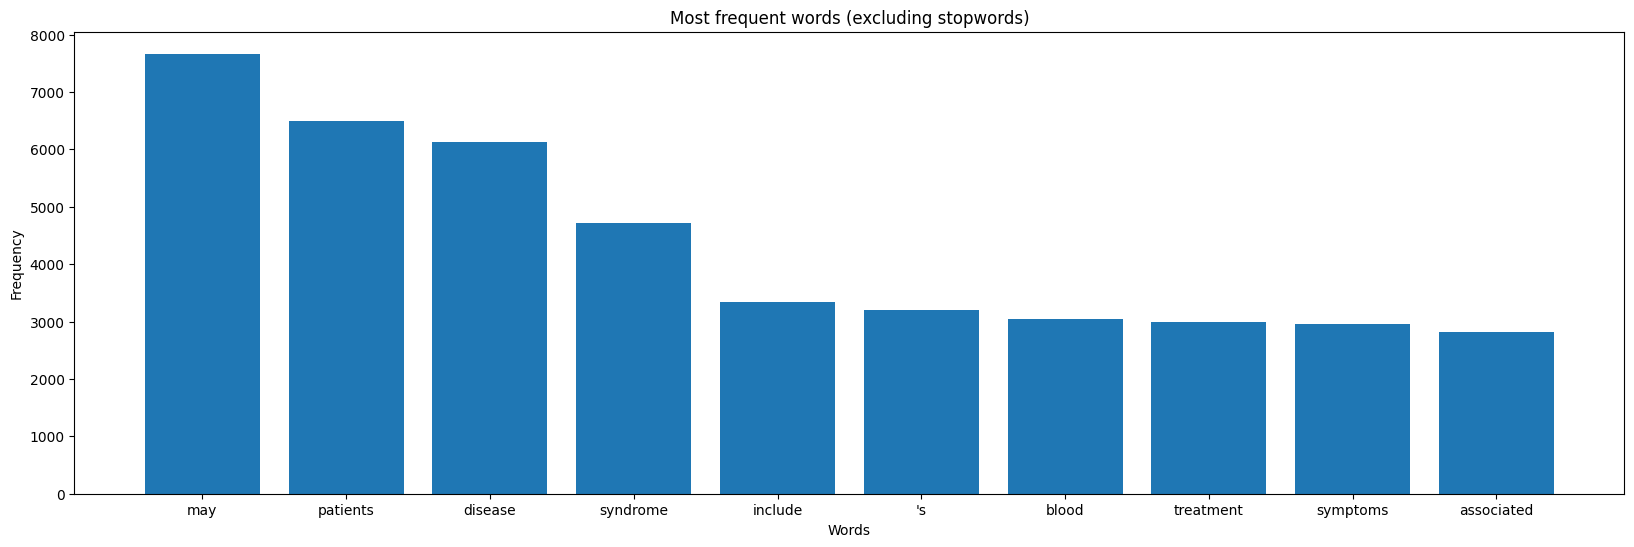

In [ ]:
# plot the most common words
def plot_most_common_words(words, frequencies):
    plt.figure(figsize=(20, 6))
    plt.bar(words, frequencies)
    plt.title('Most frequent words (excluding stopwords)')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.show()

words, frequencies = zip(*most_common_words(df_wikidoc))
plot_most_common_words(words, frequencies)

Let's see the distribution of the length of the questions and the answers in the dataset.

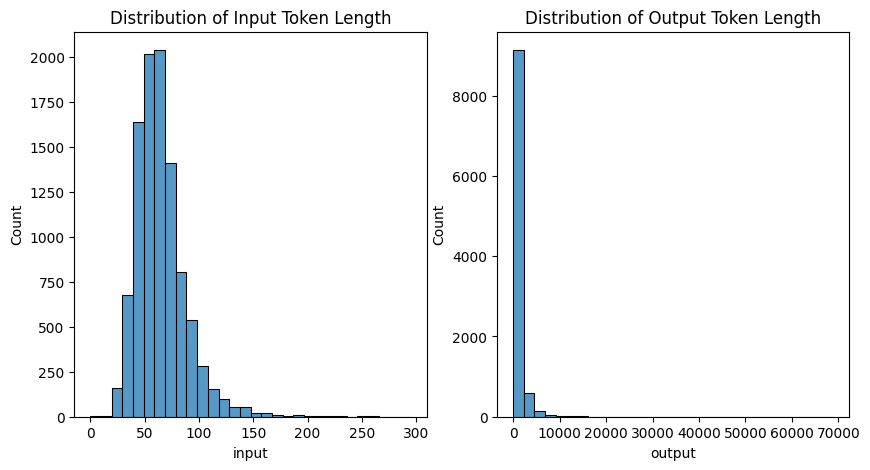

In [ ]:
def plot_token_length_distribution(df):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df['input'].apply(len), bins=30)
    plt.title('Distribution of Input Token Length')
    plt.subplot(1, 2, 2)
    sns.histplot(df['output'].apply(len), bins=30)
    plt.title('Distribution of Output Token Length')
    plt.show()

plot_token_length_distribution(df_wikidoc)

We can also check if our dataset respect the topics and categories analysis we did before for the medical flashcards dataset.

In [ ]:
data_pairs = []
# Iterate over dialogues
for index, row in df_wikidoc.iterrows():
    # Add pair to collection
    data_pairs.append(
        {'message': row['input'], 'response': row['output']}
    )

documents_wikidoc = [f"{sample['message']}\n\n{sample['response']}" for sample in data_pairs]

# vectorize the matrix
tfidf_matrix_wikidoc = vectorizer.transform(documents_wikidoc)

In [ ]:
# Funzione per assegnare i cluster
def assign_clusters(tfidf_matrix, centroids):
    cluster_labels, _ = pairwise_distances_argmin_min(tfidf_matrix, centroids)
    return cluster_labels

In [ ]:
df_wikidoc['cluster'] = assign_clusters(tfidf_matrix_wikidoc, centroids)
df_wikidoc.head()

,input,output,tokens_questions,tokens_answers,combined_tokens,cluster
0,can you provide an overview of the lung's squa...,squamous cell carcinoma of the lung may be cla...,"[provide, overview, lung, 's, squamous, cell, ...","[squamous, cell, carcinoma, lung, may, classif...","[provide, overview, lung, 's, squamous, cell, ...",7
1,"what does ""clear: cell"" mean?",clear cell tumors are part of the surface epit...,"[``, clear, cell, '', mean]","[clear, cell, tumors, part, surface, epithelia...","[``, clear, cell, '', mean, clear, cell, tumor...",0
2,can you provide me with information regarding ...,two japanese scientists commenced research int...,"[provide, information, regarding, statins]","[two, japanese, scientists, commenced, researc...","[provide, information, regarding, statins, two...",2
3,what are the historical background and symptom...,symptoms of vulvovaginitis caused by candida s...,"[historical, background, symptoms, candida-ind...","[symptoms, vulvovaginitis, caused, candida, sp...","[historical, background, symptoms, candida-ind...",9
4,"what does the ""hypotension: resident survival ...",hypotension is the term for low blood pressure...,"[``, hypotension, resident, survival, guide, '...","[hypotension, term, low, blood, pressure, bp, ...","[``, hypotension, resident, survival, guide, '...",9


### MedQA

The MedQA dataset is a question-answering dataset in the medical domain, which contains 1,000 questions and answers.

Let's load the dataset and create a dataframe to analyze it.

In [ ]:
df_medqa = pd.DataFrame(medqa)
df_medqa.head()

,instruction,input,output
0,Please answer with one of the option in the br...,Q:A 23-year-old pregnant woman at 22 weeks ges...,E: Nitrofurantoin
1,Please answer with one of the option in the br...,Q:A 3-month-old baby died suddenly at night wh...,A: Placing the infant in a supine position on ...
2,Please answer with one of the option in the br...,Q:A mother brings her 3-week-old infant to the...,A: Abnormal migration of ventral pancreatic bud
3,Please answer with one of the option in the br...,Q:A pulmonary autopsy specimen from a 58-year-...,A: Thromboembolism
4,Please answer with one of the option in the br...,Q:A 20-year-old woman presents with menorrhagi...,E: Von Willebrand disease


In [ ]:
df_medqa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   instruction  10178 non-null  object
 1   input        10178 non-null  object
 2   output       10178 non-null  object
dtypes: object(3)
memory usage: 238.7+ KB


In [ ]:
len(df_medqa)

10178

As we have done for the Wikidoc dataset, we have to:

- remove any possible duplicates fromt he dataset
- lowercase all the words
- tokenize
- remove the punctuation
- remove all the stopwords

In [ ]:
remove_duplicates(df_medqa)
lowecase(df_medqa)
tokenize(df_medqa)
remove_punctuation(df_medqa)
remove_stopwords(df_medqa)

Removed 0 duplicated elements


,instruction,input,output,tokens_questions,tokens_answers,combined_tokens
0,Please answer with one of the option in the br...,q:a 23-year-old pregnant woman at 22 weeks ges...,e: nitrofurantoin,"[q, 23-year-old, pregnant, woman, 22, weeks, g...","[e, nitrofurantoin]","[q, 23-year-old, pregnant, woman, 22, weeks, g..."
1,Please answer with one of the option in the br...,q:a 3-month-old baby died suddenly at night wh...,a: placing the infant in a supine position on ...,"[q, 3-month-old, baby, died, suddenly, night, ...","[placing, infant, supine, position, firm, matt...","[q, 3-month-old, baby, died, suddenly, night, ..."
2,Please answer with one of the option in the br...,q:a mother brings her 3-week-old infant to the...,a: abnormal migration of ventral pancreatic bud,"[q, mother, brings, 3-week-old, infant, pediat...","[abnormal, migration, ventral, pancreatic, bud]","[q, mother, brings, 3-week-old, infant, pediat..."
3,Please answer with one of the option in the br...,q:a pulmonary autopsy specimen from a 58-year-...,a: thromboembolism,"[q, pulmonary, autopsy, specimen, 58-year-old,...",[thromboembolism],"[q, pulmonary, autopsy, specimen, 58-year-old,..."
4,Please answer with one of the option in the br...,q:a 20-year-old woman presents with menorrhagi...,e: von willebrand disease,"[q, 20-year-old, woman, presents, menorrhagia,...","[e, von, willebrand, disease]","[q, 20-year-old, woman, presents, menorrhagia,..."
...,...,...,...,...,...,...
10173,Please answer with one of the option in the br...,q:a 60-year-old man presents to the emergency ...,b: administer desmopressin,"[q, 60-year-old, man, presents, emergency, dep...","[b, administer, desmopressin]","[q, 60-year-old, man, presents, emergency, dep..."
10174,Please answer with one of the option in the br...,q:a 45-year-old male with a 15-year history of...,b: urine microalbumin to creatinine ratio,"[q, 45-year-old, male, 15-year, history, diabe...","[b, urine, microalbumin, creatinine, ratio]","[q, 45-year-old, male, 15-year, history, diabe..."
10175,Please answer with one of the option in the br...,q:after receiving a positive newborn screening...,b: acetaminophen,"[q, receiving, positive, newborn, screening, r...","[b, acetaminophen]","[q, receiving, positive, newborn, screening, r..."
10176,Please answer with one of the option in the br...,q:a 25-year-old man comes to the office becaus...,c: homogentisic acid oxidase,"[q, 25-year-old, man, comes, office, pain, lef...","[c, homogentisic, acid, oxidase]","[q, 25-year-old, man, comes, office, pain, lef..."


and we can plot also the 10 most frequent words

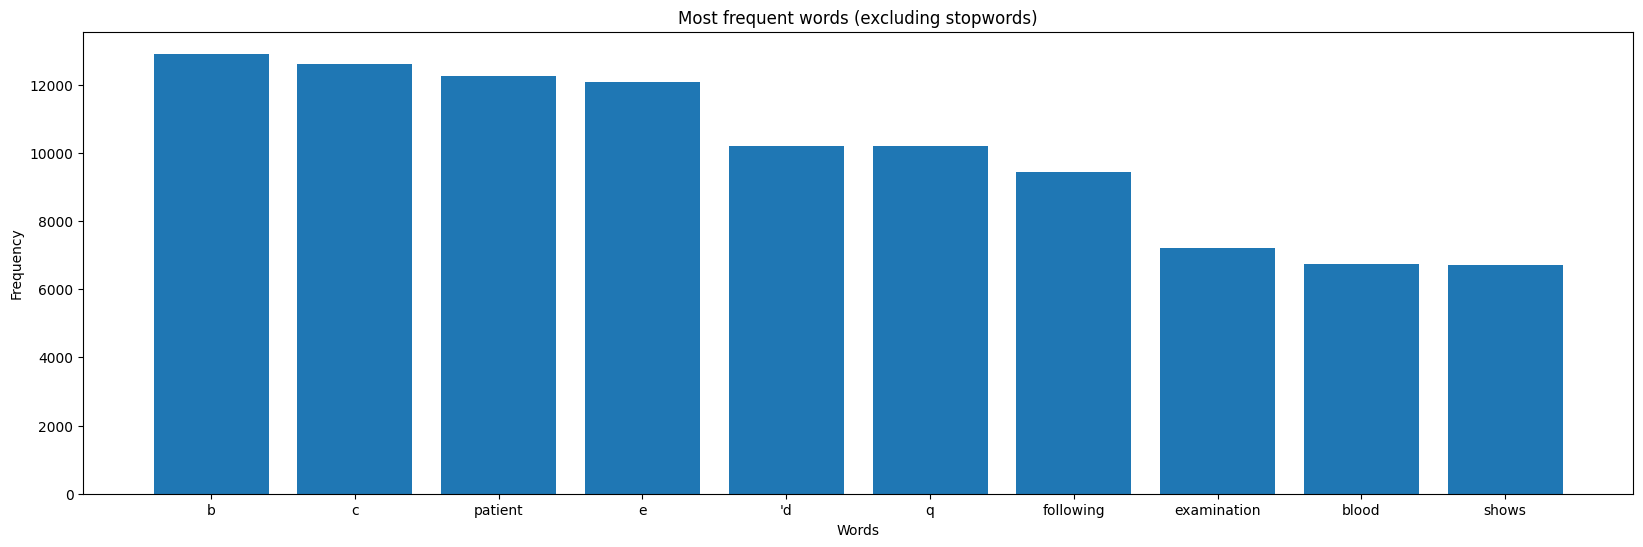

In [ ]:
words, frequencies = zip(*most_common_words(df_medqa))
plot_most_common_words(words, frequencies)

and the distribution of the tokens in each pairs

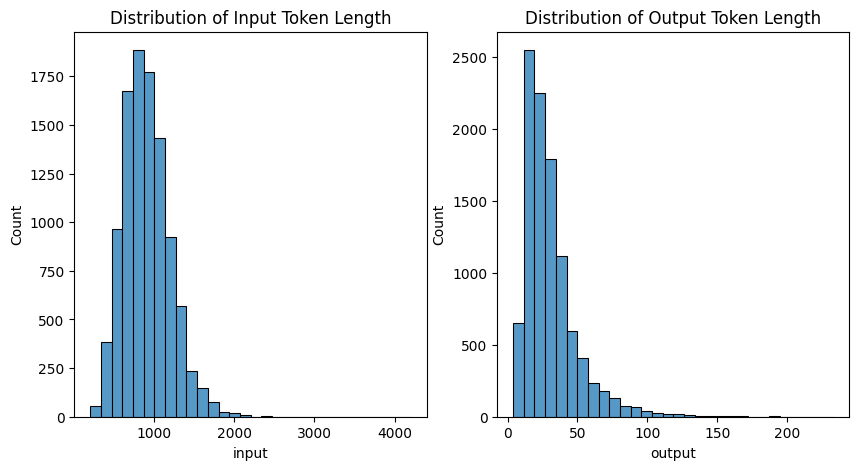

In [ ]:
plot_token_length_distribution(df_medqa)

Another interesting analysis is to find out where to place each question according to the topics we had defined for the flashcards

In [ ]:
data_pairs = []
# Iterate over dialogues
for index, row in df_medqa.iterrows():
    # Add pair to collection
    data_pairs.append(
        {'message': row['input'], 'response': row['output']}
    )

documents_medqa = [f"{sample['message']}\n\n{sample['response']}" for sample in data_pairs]
tfidf_matrix_medqa = vectorizer.transform(documents_medqa)
df_medqa['cluster'] = assign_clusters(tfidf_matrix_medqa, centroids)

df_medqa.head()

,instruction,input,output,tokens_questions,tokens_answers,combined_tokens,cluster
0,Please answer with one of the option in the br...,q:a 23-year-old pregnant woman at 22 weeks ges...,e: nitrofurantoin,"[q, 23-year-old, pregnant, woman, 22, weeks, g...","[e, nitrofurantoin]","[q, 23-year-old, pregnant, woman, 22, weeks, g...",2
1,Please answer with one of the option in the br...,q:a 3-month-old baby died suddenly at night wh...,a: placing the infant in a supine position on ...,"[q, 3-month-old, baby, died, suddenly, night, ...","[placing, infant, supine, position, firm, matt...","[q, 3-month-old, baby, died, suddenly, night, ...",2
2,Please answer with one of the option in the br...,q:a mother brings her 3-week-old infant to the...,a: abnormal migration of ventral pancreatic bud,"[q, mother, brings, 3-week-old, infant, pediat...","[abnormal, migration, ventral, pancreatic, bud]","[q, mother, brings, 3-week-old, infant, pediat...",2
3,Please answer with one of the option in the br...,q:a pulmonary autopsy specimen from a 58-year-...,a: thromboembolism,"[q, pulmonary, autopsy, specimen, 58-year-old,...",[thromboembolism],"[q, pulmonary, autopsy, specimen, 58-year-old,...",4
4,Please answer with one of the option in the br...,q:a 20-year-old woman presents with menorrhagi...,e: von willebrand disease,"[q, 20-year-old, woman, presents, menorrhagia,...","[e, von, willebrand, disease]","[q, 20-year-old, woman, presents, menorrhagia,...",11


## Conclusion

In this section, we analyzed the Medical Meadow Medical Flashcards dataset and two other medical datasets, Wikidoc and MedQA, to understand their structure and the data they contain.

We performed data preprocessing, exploratory data analysis, and topic modeling to get a better understanding of the datasets.

Now, we can display the results of the analysis and the insights we gained from the datasets all in one place.

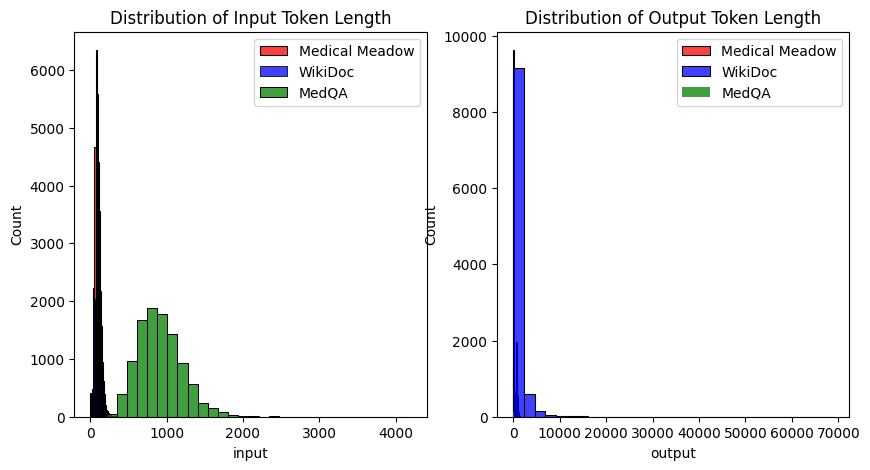

In [ ]:
def plot_token_length_distribution_all_datasets(df1, df2, df3):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df1['input'].apply(len), bins=30, color='red', label='Medical Meadow')
    sns.histplot(df2['input'].apply(len), bins=30, color='blue', label='WikiDoc')
    sns.histplot(df3['input'].apply(len), bins=30, color='green', label='MedQA')
    plt.title('Distribution of Input Token Length')
    plt.legend()

    plt.subplot(1, 2, 2)
    sns.histplot(df1['output'].apply(len), bins=30, color='red', label='Medical Meadow')
    sns.histplot(df2['output'].apply(len), bins=30, color='blue', label='WikiDoc')
    sns.histplot(df3['output'].apply(len), bins=30, color='green', label='MedQA')
    plt.title('Distribution of Output Token Length')
    plt.legend()
    plt.show()

plot_token_length_distribution_all_datasets(df, df_wikidoc, df_medqa)

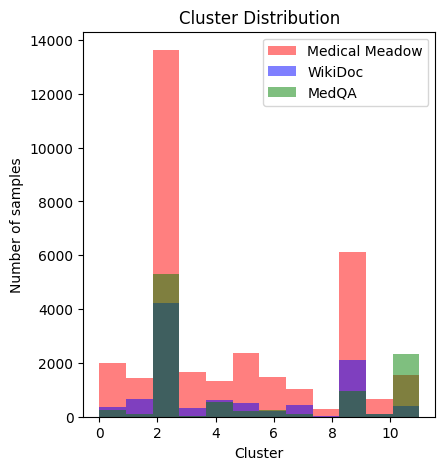

In [ ]:
def plot_cluster_distribution_all_datasets(df1, df2, df3):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.hist(df1['cluster'], bins=k, color='red', alpha=0.5, label='Medical Meadow')
    plt.hist(df2['cluster'], bins=k, color='blue', alpha=0.5, label='WikiDoc')
    plt.hist(df3['cluster'], bins=k, color='green', alpha=0.5, label='MedQA')
    plt.title('Cluster Distribution')
    plt.xlabel('Cluster')
    plt.ylabel('Number of samples')
    plt.legend()

    plt.show()

plot_cluster_distribution_all_datasets(df_unique, df_wikidoc, df_medqa)